In [9]:
import pandas as pd
import tables

raw_df = pd.read_hdf('VNAT_Dataframe_release_1.h5')
raw_df.head()

,connection,timestamps,sizes,directions,file_names
0,"(10.123.1.2, 1195, 10.123.1.1, 1195, 17)","[1563289706.330096, 1563289706.330207, 1563289...","[120, 88, 120, 88, 120, 88, 120, 120, 152, 120...","[1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, ...",vpn_youtube_capture2.pcap
0,"(10.113.1.2, 22924, 10.115.1.2, 53, 17)","[1561391908.523659, 1561391908.524042]","[63, 79]","[1, 0]",nonvpn_sftp_newcapture1.pcap
1,"(10.113.1.2, 53065, 10.115.1.2, 53, 17)","[1561391908.523706, 1561391908.524059]","[63, 63]","[1, 0]",nonvpn_sftp_newcapture1.pcap
2,"(10.113.1.150, 39816, 10.115.1.123, 22, 6)","[1561391908.524836, 1561391908.525027, 1561391...","[60, 60, 52, 73, 52, 73, 52, 1378, 222, 52, 13...","[1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, ...",nonvpn_sftp_newcapture1.pcap
3,"(10.115.1.2, 6589, 10.113.1.2, 53, 17)","[1561391908.594887, 1561391908.595301]","[51, 102]","[1, 0]",nonvpn_sftp_newcapture1.pcap


In [10]:
feature_df = pd.read_hdf('VNAT_Feature_Dataframe_release_1.h5')
feature_df.head()

,out_iat_min,out_iat_max,out_iat_mean,out_iat_std_dev,in_iat_min,in_iat_max,in_iat_mean,in_iat_std_dev,flow_iat_min,flow_iat_max,...,out_log_std_dev_detail_coeffs_4,out_log_std_dev_detail_coeffs_5,out_log_std_dev_detail_coeffs_6,out_log_std_dev_detail_coeffs_7,out_log_std_dev_detail_coeffs_8,out_log_std_dev_detail_coeffs_9,out_log_std_dev_detail_coeffs_10,out_log_std_dev_detail_coeffs_11,out_log_std_dev_detail_coeffs_12,labels
0,0.000024,15.646865,0.891706,3.579154,0.000054,15.607829,0.842655,3.480432,0.000024,15.607655,...,0.958770,1.279343,1.569488,1.790519,2.070103,2.096996,2.428894,2.759263,2.904293,C2
1,0.001351,10.258183,3.232542,2.992364,0.018239,10.202419,1.941929,2.765867,0.000105,10.202419,...,0.251599,0.637307,1.005774,1.309230,1.554615,1.820888,2.220975,2.554422,2.914594,CHAT
2,0.028768,4.019976,1.227752,1.278413,0.026368,3.980284,1.123653,1.264388,0.001719,3.978565,...,0.014055,0.420507,0.762716,1.109513,1.471456,1.754881,2.001594,2.351996,2.736217,CHAT
3,0.030268,3.264299,1.456833,1.292042,0.029519,3.226012,1.458189,1.291581,0.001323,3.224246,...,0.023604,0.542705,0.945885,1.278526,1.571150,1.862637,2.113894,2.454169,2.844140,CHAT
4,0.025157,3.391598,1.068763,1.193896,0.028530,3.332177,1.131416,1.185435,0.001574,3.329872,...,0.155742,0.459030,0.914504,1.178986,1.553150,1.858731,2.111992,2.449052,2.836318,CHAT


In [18]:
raw_df = raw_df.drop(columns='app_name')

In [11]:
feature_df.shape

(15093, 130)

In [12]:
raw_df.shape

(33711, 5)

In [ ]:
#Parse file names to extract vpn vs non vpn
raw_df['is_vpn'] = raw_df['file_names'].str.startswith('vpn_')

# Extract app name from filename
raw_df['app'] = raw_df['file_names'].str.extract(r'(?:non)?vpn_(.+?)_(?:new)?capture')

# Map app to category
app_to_category = {
    'netflix':      'STREAMING',
    'youtube':      'STREAMING',
    'vimeo':        'STREAMING',
    'voip':         'VOIP',
    'skype-chat':   'CHAT',
    'sftp':         'FILE_TRANSFER',
    'scp':          'FILE_TRANSFER',
    'scp_long':     'FILE_TRANSFER',   # nonvpn_scp_long_capture1.pcap
    'rsync':        'FILE_TRANSFER',
    'ssh':          'FILE_TRANSFER',
    'rdp':          'C2',
}

raw_df['category'] = raw_df['app'].map(app_to_category)

raw_df.head()

In [14]:
raw_df['is_vpn'].value_counts()

is_vpn
False    33332
True       379
Name: count, dtype: int64

In [20]:
# â”€â”€ Label Distribution & Filename Validation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# raw_df has duplicate index labels from the HDF5 load; reset for safe ops
df = raw_df.reset_index(drop=True)

# 1. Malformed filenames: regex failed to extract app name
malformed = df[df['app'].isna()]
print(f"Malformed filenames (app extraction failed): {len(malformed)}")
if not malformed.empty:
    print(malformed['file_names'].unique())

# 2. Unmapped apps: app extracted but not in app_to_category
unmapped = df[df['app'].notna() & df['category'].isna()]
print(f"\nUnmapped app names (no category assignment): {len(unmapped)}")
if not unmapped.empty:
    print(unmapped[['file_names', 'app']].drop_duplicates())

# 3. All unique filenames â€” eyeball for anomalies
print(f"\nAll unique file_names ({df['file_names'].nunique()} total):")
print(sorted(df['file_names'].unique()))

# 4. Label distributions
print("\nâ”€â”€ VPN Status â”€â”€")
print(df['is_vpn'].value_counts())

print("\nâ”€â”€ Traffic Category â”€â”€")
print(df['category'].value_counts(dropna=False))

print("\nâ”€â”€ Application â”€â”€")
print(df['app'].value_counts(dropna=False))

# 5. Cross-tab: category Ã— vpn
print("\nâ”€â”€ Category Ã— VPN Status â”€â”€")
print(pd.crosstab(df['category'], df['is_vpn'], margins=True))

Malformed filenames (app extraction failed): 0

Unmapped app names (no category assignment): 10555
                         file_names       app
1646  nonvpn_scp_long_capture1.pcap  scp_long

All unique file_names (165 total):
['nonvpn_netflix_capture1.pcap', 'nonvpn_netflix_capture2.pcap', 'nonvpn_rdp_capture1.pcap', 'nonvpn_rdp_capture2.pcap', 'nonvpn_rdp_capture3.pcap', 'nonvpn_rdp_capture4.pcap', 'nonvpn_rdp_capture_5.pcap', 'nonvpn_rsync_capture1.pcap', 'nonvpn_rsync_newcapture1.pcap', 'nonvpn_scp_capture1.pcap', 'nonvpn_scp_long_capture1.pcap', 'nonvpn_scp_newcapture1.pcap', 'nonvpn_sftp_capture1.pcap', 'nonvpn_sftp_capture2.pcap', 'nonvpn_sftp_capture3.pcap', 'nonvpn_sftp_newcapture1.pcap', 'nonvpn_sftp_newcapture2.pcap', 'nonvpn_skype-chat_capture1.pcap', 'nonvpn_skype-chat_capture10.pcap', 'nonvpn_skype-chat_capture11.pcap', 'nonvpn_skype-chat_capture12.pcap', 'nonvpn_skype-chat_capture13.pcap', 'nonvpn_skype-chat_capture14.pcap', 'nonvpn_skype-chat_capture15.pcap', 'nonvpn_sk

Per-flow stats â€” computes pkt_count, duration, total_bytes for every row. The describe() table will show the range â€” expect heavy right skew (mean >> median).

In [21]:
# â”€â”€ Per-flow stats â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df['pkt_count']   = df['sizes'].apply(len)
df['duration']    = df['timestamps'].apply(lambda t: t[-1] - t[0] if len(t) > 1 else 0.0)
df['total_bytes'] = df['sizes'].apply(sum)

df[['pkt_count', 'duration', 'total_bytes']].describe()

,pkt_count,duration,total_bytes
count,3.371100e+04,33711.000000,3.371100e+04
mean,1.130292e+03,379.621814,1.037376e+06
std,3.741679e+04,2480.214637,3.704212e+07
min,1.000000e+00,0.000000,2.100000e+01
25%,2.000000e+00,0.000358,1.260000e+02
50%,2.000000e+00,0.000415,1.340000e+02
75%,2.000000e+00,0.000600,1.530000e+02
max,3.842411e+06,142910.249806,3.858275e+09


Data quality â€” flags empty flows (can't extract any features) and single-packet flows (duration = 0, no inter-arrival times, most timing features undefined). These need to be dropped before feature engineering.


In [22]:
# â”€â”€ Data quality issues â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
empty_flows  = df[df['pkt_count'] == 0]
single_flows = df[df['pkt_count'] == 1]

print(f"Empty flows (0 packets):        {len(empty_flows)}")
print(f"Single-packet flows (duration=0): {len(single_flows)}")
print(f"\nTop outliers by packet count:")
print(df['pkt_count'].nlargest(5))
print(f"\nTop outliers by total bytes:")
print(df['total_bytes'].nlargest(5))

Empty flows (0 packets):        0
Single-packet flows (duration=0): 27

Top outliers by packet count:
12325    3842411
972      3739465
12464    2240881
3        2002346
13924    1361406
Name: pkt_count, dtype: int64

Top outliers by total bytes:
12325    3858275080
972      3811032904
12464    2234841512
3        1826811992
13924    1359311728
Name: total_bytes, dtype: int64


VPN vs Non-VPN plots â€” log-scaled histograms. If VPN tunneling meaningfully changes traffic patterns you should see distributional shifts, especially in packet count and duration. If the distributions are near-identical, VPN detection will be harder than expected.


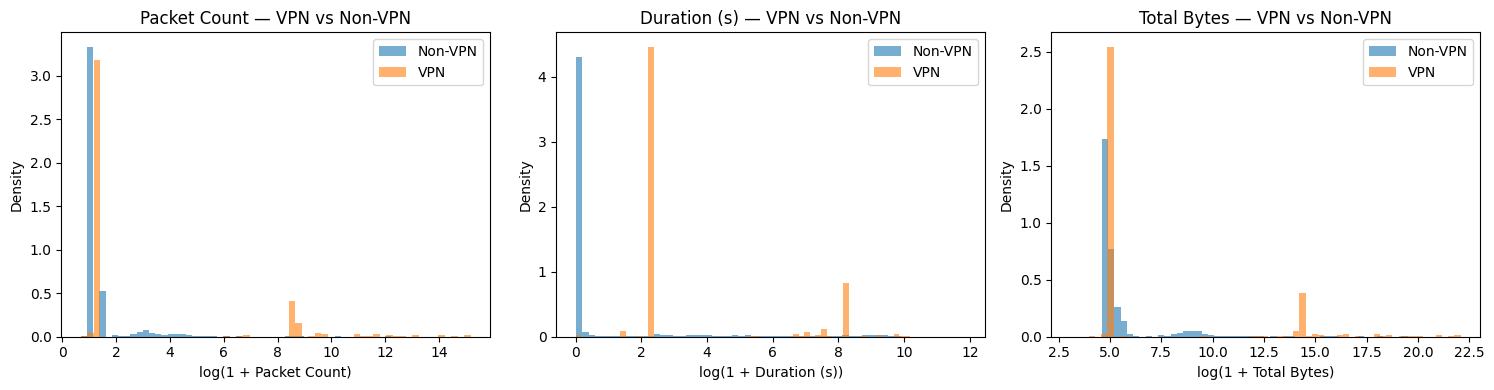

In [24]:
# â”€â”€ Distributions: VPN vs Non-VPN â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('pkt_count', 'Packet Count'), ('duration', 'Duration (s)'), ('total_bytes', 'Total Bytes')]

for ax, (col, label) in zip(axes, metrics):
    for is_vpn, grp in df.groupby('is_vpn'):
        vals = np.log1p(grp[col])
        ax.hist(vals, bins=60, alpha=0.6, label='VPN' if is_vpn else 'Non-VPN', density=True)
    ax.set_xlabel(f'log(1 + {label})')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} â€” VPN vs Non-VPN')
    ax.legend()

plt.tight_layout()
plt.show()


By-category plots â€” same three metrics broken out by category. C2 (RDP) and VOIP should look distinct from FILE_TRANSFER and CHAT. Heavy overlap between categories is a signal that raw volume/duration features alone won't be enough and timing/wavelet features will matter.


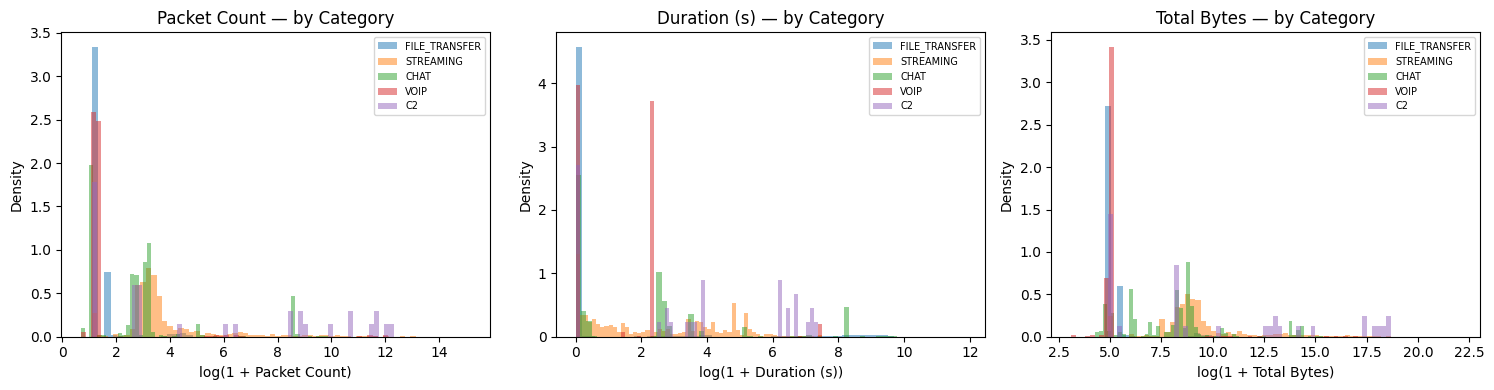

In [25]:
# â”€â”€ Distributions: across 5 traffic categories â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cat_df = df.dropna(subset=['category'])
category_order = cat_df['category'].value_counts().index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, label) in zip(axes, metrics):
    for cat in category_order:
        vals = np.log1p(cat_df.loc[cat_df['category'] == cat, col])
        ax.hist(vals, bins=60, alpha=0.5, label=cat, density=True)
    ax.set_xlabel(f'log(1 + {label})')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} â€” by Category')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


Also note: the scp_long fix resolves 10,555 previously unmapped rows â€” re-run the validation cell first to confirm 0 unmapped before running EDA.

In [27]:
# Drop unusable flows
# Single-packet flows: no inter-arrival times, timing features undefined.
# Unlabelled rows: guard in case scp_long fix not yet applied.
clean_df = df[(df['pkt_count'] > 1) & df['category'].notna()].copy()
print(f"Rows before: {len(df):,}  ->  after dropping single-pkt & unlabelled: {len(clean_df):,}")
print(clean_df['category'].value_counts())

Rows before: 33,711  ->  after dropping single-pkt & unlabelled: 23,129
category
FILE_TRANSFER    19438
STREAMING         1764
CHAT              1281
VOIP               610
C2                  36
Name: count, dtype: int64


In [29]:
import numpy as np
import pywt

# Cap signal length fed to wavelet -- flows with millions of packets (scp_long)
# would otherwise take minutes per row.
MAX_PKTS     = 2048
WAVELET      = 'haar'
WAV_LEVELS   = 12
IDLE_THRESH  = 1.0   # seconds -- gap >= this is 'idle'
BURST_THRESH = 0.1   # seconds -- gap >= this breaks a burst


def _iat_stats(times, tag, feats):
    if len(times) > 1:
        iats = np.diff(times)
        feats[f'{tag}_iat_min']  = float(iats.min())
        feats[f'{tag}_iat_max']  = float(iats.max())
        feats[f'{tag}_iat_mean'] = float(iats.mean())
        feats[f'{tag}_iat_std']  = float(iats.std())
        return iats
    for s in ('min', 'max', 'mean', 'std'):
        feats[f'{tag}_iat_{s}'] = 0.0
    return np.array([0.0])


def _size_stats(sizes, tag, feats):
    if len(sizes) > 0:
        feats[f'{tag}_size_min']    = float(sizes.min())
        feats[f'{tag}_size_max']    = float(sizes.max())
        feats[f'{tag}_size_mean']   = float(sizes.mean())
        feats[f'{tag}_size_std']    = float(sizes.std())
        feats[f'{tag}_size_median'] = float(np.median(sizes))
        feats[f'{tag}_size_p25']    = float(np.percentile(sizes, 25))
        feats[f'{tag}_size_p75']    = float(np.percentile(sizes, 75))
    else:
        for s in ('min', 'max', 'mean', 'std', 'median', 'p25', 'p75'):
            feats[f'{tag}_size_{s}'] = 0.0


def _entropy(sizes, bins=20):
    if len(sizes) == 0:
        return 0.0
    counts, _ = np.histogram(sizes, bins=bins)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


def _wavelet_features(sizes, tag, feats, levels=WAV_LEVELS):
    sig = sizes[:MAX_PKTS].astype(float)
    if len(sig) < 2:
        sig = np.pad(sig, (0, 2 - len(sig)))
    coeffs = pywt.wavedec(sig, WAVELET, level=levels, mode='periodization')
    # coeffs = [cA_N, cD_N, cD_{N-1}, ..., cD_1]
    detail = coeffs[1:]
    total_energy = sum(np.sum(c ** 2) for c in coeffs)
    for i, cd in enumerate(detail, start=1):
        feats[f'{tag}_log_mean_detail_coeffs_{i}']    = float(np.log1p(np.abs(cd).mean()))
        feats[f'{tag}_log_std_dev_detail_coeffs_{i}'] = float(np.log1p(cd.std()))
        level_energy = float(np.sum(cd ** 2))
        feats[f'{tag}_rel_energy_{i}'] = level_energy / total_energy if total_energy > 0 else 0.0


def extract_features(row):
    sizes = np.array(row['sizes'],      dtype=float)
    times = np.array(row['timestamps'], dtype=float)
    dirs  = np.array(row['directions'], dtype=int)   # 1=out, 0=in

    out_mask  = dirs == 1
    in_mask   = dirs == 0
    out_sizes = sizes[out_mask]
    in_sizes  = sizes[in_mask]
    out_times = times[out_mask]
    in_times  = times[in_mask]
    feats = {}

    # Volume
    total_bytes = float(sizes.sum())
    duration    = float(times[-1] - times[0])
    feats['log_out_pkt_count'] = float(np.log1p(out_mask.sum()))
    feats['log_in_pkt_count']  = float(np.log1p(in_mask.sum()))
    feats['log_out_bytes']     = float(np.log1p(out_sizes.sum()))
    feats['log_in_bytes']      = float(np.log1p(in_sizes.sum()))
    feats['dir_ratio']         = float(out_sizes.sum() / total_bytes) if total_bytes > 0 else 0.5
    feats['bytes_per_sec']     = total_bytes / duration if duration > 0 else 0.0
    _size_stats(out_sizes, 'out', feats)
    _size_stats(in_sizes,  'in',  feats)

    # Timing
    flow_iats = _iat_stats(times,     'flow', feats)
    _iat_stats(out_times, 'out',  feats)
    _iat_stats(in_times,  'in',   feats)

    # Active / idle
    idle_gaps   = flow_iats[flow_iats >= IDLE_THRESH]
    active_gaps = flow_iats[flow_iats <  IDLE_THRESH]
    feats['idle_time']   = float(idle_gaps.sum())
    feats['active_time'] = float(active_gaps.sum())
    feats['n_idle']      = int(len(idle_gaps))

    # Bursts
    breaks       = np.where(flow_iats >= BURST_THRESH)[0]
    burst_pkts   = np.split(sizes, breaks + 1)
    burst_starts = np.concatenate([[0], breaks + 1])
    burst_ends   = np.concatenate([breaks + 1, [len(times)]])
    burst_durs   = [float(times[e-1] - times[s]) for s, e in zip(burst_starts, burst_ends) if e > s]
    feats['n_bursts']        = int(len(breaks) + 1)
    feats['mean_burst_pkts'] = float(np.mean([len(b) for b in burst_pkts]))
    feats['mean_burst_dur']  = float(np.mean(burst_durs)) if burst_durs else 0.0

    # Entropy
    feats['out_size_entropy']  = _entropy(out_sizes)
    feats['in_size_entropy']   = _entropy(in_sizes)
    feats['flow_size_entropy'] = _entropy(sizes)

    # Wavelet
    if len(out_sizes) >= 2:
        _wavelet_features(out_sizes, 'out', feats)
    if len(in_sizes) >= 2:
        _wavelet_features(in_sizes, 'in', feats)

    return feats

print('extract_features defined')

extract_features defined


In [30]:
# Apply feature extraction (~2-5 min for 33k rows)
from tqdm.notebook import tqdm
tqdm.pandas()

feat_records = clean_df.progress_apply(extract_features, axis=1)
feat_matrix  = pd.DataFrame(feat_records.tolist(), index=clean_df.index)

print(f'Feature matrix: {feat_matrix.shape}')
print('NaN counts (should all be 0):')
print(feat_matrix.isna().sum().value_counts())

  0%|          | 0/23129 [00:00<?, ?it/s]

c:\Users\apier\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 12 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Feature matrix: (23129, 113)
NaN counts (should all be 0):
0        41
16010    36
16352    36
Name: count, dtype: int64


In [31]:
# Assemble final labelled feature dataframe
# Reset index so concat aligns correctly, fill NaNs from direction-only flows
# (e.g. all-outbound flows produce NaN for in_* wavelet features).
feat_matrix_reset = feat_matrix.reset_index(drop=True)
label_cols = clean_df[['is_vpn', 'app', 'category']].reset_index(drop=True)

features = pd.concat([feat_matrix_reset, label_cols], axis=1).fillna(0)

print(features.shape)
features.head()

(23129, 116)


,log_out_pkt_count,log_in_pkt_count,log_out_bytes,log_in_bytes,dir_ratio,bytes_per_sec,out_size_min,out_size_max,out_size_mean,out_size_std,...,in_rel_energy_10,in_log_mean_detail_coeffs_11,in_log_std_dev_detail_coeffs_11,in_rel_energy_11,in_log_mean_detail_coeffs_12,in_log_std_dev_detail_coeffs_12,in_rel_energy_12,is_vpn,app,category
0,9.916108,10.646163,14.852035,17.832095,0.048335,7.286141e+04,88.0,1448.0,139.209006,129.238237,...,0.010160,5.500812,5.912749,0.012785,5.276400,5.902365,0.024993,True,youtube,STREAMING
1,0.693147,0.693147,4.158883,4.382027,0.443662,3.708538e+05,63.0,63.0,63.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,sftp,FILE_TRANSFER
2,0.693147,0.693147,4.158883,4.158883,0.500000,3.568415e+05,63.0,63.0,63.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,sftp,FILE_TRANSFER
3,13.732254,13.894537,20.328655,20.865520,0.368917,3.859252e+06,52.0,1378.0,732.455010,659.871083,...,0.024525,2.683066,3.782950,0.052880,2.352396,3.466488,0.055188,False,sftp,FILE_TRANSFER
4,0.693147,0.693147,3.951244,4.634729,0.333333,3.696593e+05,51.0,51.0,51.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,sftp,FILE_TRANSFER


In [32]:
# Save to CSV
features.to_csv('features.csv', index=False)
print(f'Saved features.csv  ({features.shape[0]:,} rows x {features.shape[1]} cols)')
print(features['category'].value_counts())

Saved features.csv  (23,129 rows x 116 cols)
category
FILE_TRANSFER    19438
STREAMING         1764
CHAT              1281
VOIP               610
C2                  36
Name: count, dtype: int64


## Phase 2: Baseline Classification

In [33]:
# Load features if starting fresh from CSV
# (skip this cell if features df is already in memory)
import pandas as pd
features = pd.read_csv('features.csv')
print(features.shape)
print(features['category'].value_counts())

(23129, 116)
category
FILE_TRANSFER    19438
STREAMING         1764
CHAT              1281
VOIP               610
C2                  36
Name: count, dtype: int64


In [34]:
# Step 2.1 -- Stratified train / val / test split (70 / 15 / 15)
from sklearn.model_selection import train_test_split

X = features.drop(columns=['is_vpn', 'app', 'category'])
y_cat = features['category']
y_vpn = features['is_vpn'].astype(int)

# First cut: 70% train, 30% temp -- stratify on category (most imbalanced)
X_train, X_temp, y_cat_train, y_cat_temp, y_vpn_train, y_vpn_temp = train_test_split(
    X, y_cat, y_vpn,
    test_size=0.30, random_state=42, stratify=y_cat
)

# Second cut: split temp 50/50 -> 15% val, 15% test
X_val, X_test, y_cat_val, y_cat_test, y_vpn_val, y_vpn_test = train_test_split(
    X_temp, y_cat_temp, y_vpn_temp,
    test_size=0.50, random_state=42, stratify=y_cat_temp
)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print()
print("Category distribution (proportions):")
for split, y in [('Train', y_cat_train), ('Val', y_cat_val), ('Test', y_cat_test)]:
    print(f"  {split}: {y.value_counts(normalize=True).round(3).to_dict()}")

Train: 16,190  Val: 3,469  Test: 3,470

Category distribution (proportions):
  Train: {'FILE_TRANSFER': 0.84, 'STREAMING': 0.076, 'CHAT': 0.055, 'VOIP': 0.026, 'C2': 0.002}
  Val: {'FILE_TRANSFER': 0.841, 'STREAMING': 0.076, 'CHAT': 0.055, 'VOIP': 0.026, 'C2': 0.002}
  Test: {'FILE_TRANSFER': 0.84, 'STREAMING': 0.076, 'CHAT': 0.055, 'VOIP': 0.027, 'C2': 0.001}


Training set class counts and imbalance ratio vs majority:
  FILE_TRANSFER   13606  (1.000x)
  STREAMING        1235  (0.091x)
  CHAT              897  (0.066x)
  VOIP              427  (0.031x)
  C2                 25  (0.002x)


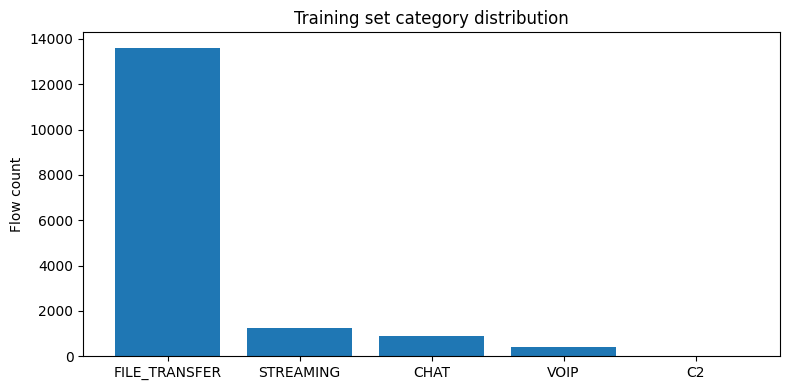

In [35]:
# Step 2.2 -- Class imbalance analysis
import matplotlib.pyplot as plt
import numpy as np

counts = y_cat_train.value_counts()
ratios = counts / counts.max()

print("Training set class counts and imbalance ratio vs majority:")
for cls, n in counts.items():
    print(f"  {cls:<15} {n:>5}  ({ratios[cls]:.3f}x)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts.index, counts.values)
ax.set_ylabel('Flow count')
ax.set_title('Training set category distribution')
plt.tight_layout()
plt.show()

In [36]:
# Class weights (inverse-frequency) -- no data augmentation, works with all models
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_cat_train)
weights = compute_class_weight('balanced', classes=classes, y=y_cat_train)
class_weight_dict = dict(zip(classes, weights))

print("Class weights (balanced):")
for cls, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    print(f"  {cls:<15} {w:.3f}")

Class weights (balanced):
  C2              129.520
  VOIP            7.583
  CHAT            3.610
  STREAMING       2.622
  FILE_TRANSFER   0.238


### Step 2.3 — Train Baseline Models (Task A: Traffic Category, 5-class)

In [37]:
# Shared evaluation helper
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

def evaluate(name, model, X_val, y_val):
    preds = model.predict(X_val)
    macro_f1 = f1_score(y_val, preds, average='macro')
    print(f"=== {name}  (macro F1: {macro_f1:.4f}) ===")
    print(classification_report(y_val, preds))

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_val, preds, ax=ax, colorbar=False,
                                            xticks_rotation=30)
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return macro_f1

c:\Users\apier\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Logistic Regression  (macro F1: 0.7027) ===
               precision    recall  f1-score   support

           C2       0.05      0.67      0.10         6
         CHAT       0.99      0.92      0.95       192
FILE_TRANSFER       0.99      0.93      0.96      2916
    STREAMING       0.97      0.96      0.97       264
         VOIP       0.37      0.95      0.54        91

     accuracy                           0.93      3469
    macro avg       0.68      0.88      0.70      3469
 weighted avg       0.97      0.93      0.95      3469



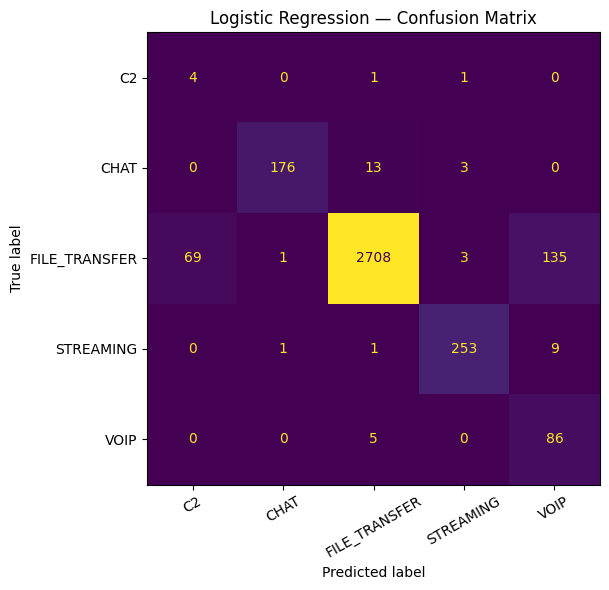

In [38]:
# Logistic Regression -- baseline reference
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict,
        random_state=42,
        n_jobs=-1
    ))
])
lr.fit(X_train, y_cat_train)
lr_f1 = evaluate('Logistic Regression', lr, X_val, y_cat_val)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 400}
=== Random Forest  (macro F1: 0.8581) ===
               precision    recall  f1-score   support

           C2       0.24      0.67      0.35         6
         CHAT       0.98      0.99      0.99       192
FILE_TRANSFER       1.00      0.99      1.00      2916
    STREAMING       0.97      1.00      0.99       264
         VOIP       0.99      0.96      0.97        91

     accuracy                           0.99      3469
    macro avg       0.84      0.92      0.86      3469
 weighted avg       0.99      0.99      0.99      3469



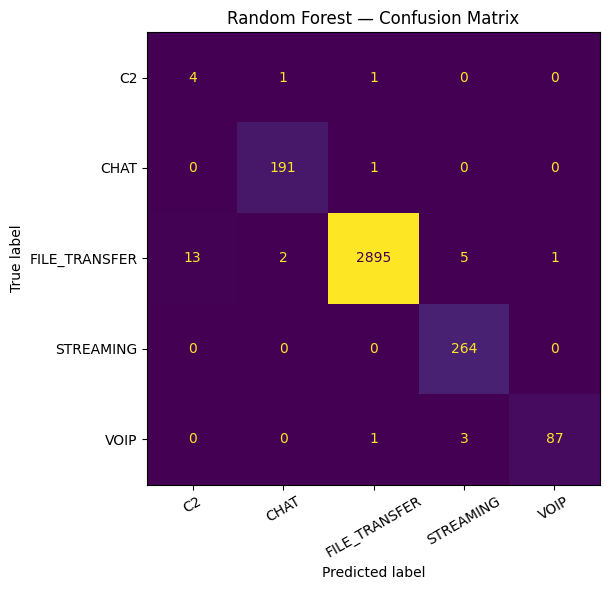

In [39]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth':    [None, 20],
    'min_samples_leaf': [1, 5],
}

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_cat_train)

print(f"Best RF params: {rf_search.best_params_}")
rf_f1 = evaluate('Random Forest', rf_search.best_estimator_, X_val, y_cat_val)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best LGBM params: {'learning_rate': 0.05, 'min_child_samples': 30, 'n_estimators': 400, 'num_leaves': 63}
=== LightGBM  (macro F1: 0.8998) ===
               precision    recall  f1-score   support

           C2       0.38      0.83      0.53         6
         CHAT       1.00      0.99      1.00       192
FILE_TRANSFER       1.00      1.00      1.00      2916
    STREAMING       0.99      1.00      0.99       264
         VOIP       1.00      0.97      0.98        91

     accuracy                           1.00      3469
    macro avg       0.88      0.96      0.90      3469
 weighted avg       1.00      1.00      1.00      3469



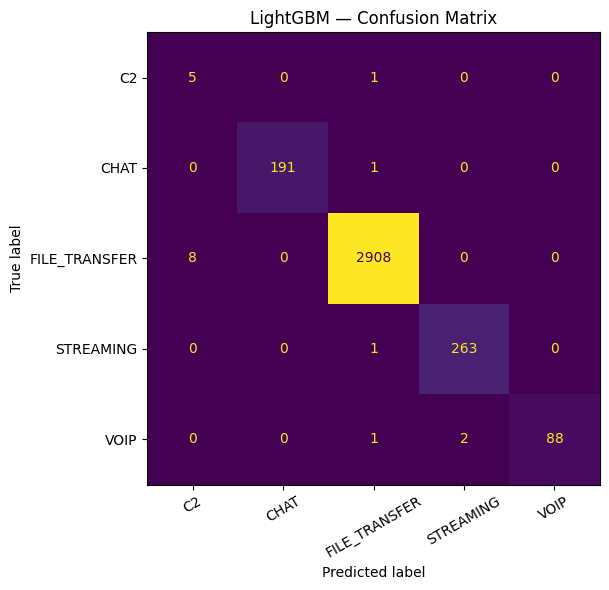

In [40]:
# LightGBM
from lightgbm import LGBMClassifier

# Convert string class weights to per-sample weights (LightGBM sample_weight)
import numpy as np
sample_weights = y_cat_train.map(class_weight_dict).values

lgbm_param_grid = {
    'learning_rate':  [0.05, 0.1],
    'num_leaves':     [31, 63],
    'n_estimators':   [200, 400],
    'min_child_samples': [10, 30],
}

lgbm_search = GridSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    lgbm_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
lgbm_search.fit(X_train, y_cat_train, sample_weight=sample_weights)

print(f"Best LGBM params: {lgbm_search.best_params_}")
lgbm_f1 = evaluate('LightGBM', lgbm_search.best_estimator_, X_val, y_cat_val)

In [42]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'Val macro-F1': [lr_f1, rf_f1, lgbm_f1],
}).sort_values('Val macro-F1', ascending=False)

print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
print(f"Best model: {best_model_name}")

              Model  Val macro-F1
           LightGBM      0.899843
      Random Forest      0.858095
Logistic Regression      0.702739
Best model: LightGBM


### Step 2.3 — Task B: VPN Status Classification (binary)

In [43]:
# VPN class imbalance -- much more severe than category imbalance
vpn_counts = y_vpn_train.value_counts()
print("Training set VPN distribution:")
print(f"  Non-VPN (0): {vpn_counts[0]:,}  ({vpn_counts[0]/len(y_vpn_train):.1%})")
print(f"  VPN     (1): {vpn_counts[1]:,}  ({vpn_counts[1]/len(y_vpn_train):.1%})")
print(f"  Imbalance ratio: {vpn_counts[0]/vpn_counts[1]:.0f}:1")

Training set VPN distribution:
  Non-VPN (0): 15,914  (98.3%)
  VPN     (1): 276  (1.7%)
  Imbalance ratio: 58:1


In [44]:
# Shared binary evaluation helper (adds ROC-AUC and precision-recall curve)
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              f1_score, roc_auc_score,
                              PrecisionRecallDisplay)
import matplotlib.pyplot as plt

def evaluate_binary(name, model, X_val, y_val):
    preds  = model.predict(X_val)
    probas = model.predict_proba(X_val)[:, 1]

    macro_f1 = f1_score(y_val, preds, average='macro')
    auc      = roc_auc_score(y_val, probas)

    print(f"=== {name}  (macro F1: {macro_f1:.4f}  ROC-AUC: {auc:.4f}) ===")
    print(classification_report(y_val, preds, target_names=['Non-VPN', 'VPN']))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_val, preds, ax=ax1, colorbar=False,
        display_labels=['Non-VPN', 'VPN'])
    ax1.set_title(f'{name} — Confusion Matrix')

    PrecisionRecallDisplay.from_predictions(y_val, probas, ax=ax2,
                                             name=name)
    ax2.set_title(f'{name} — Precision-Recall Curve')
    plt.tight_layout()
    plt.show()
    return macro_f1, auc

c:\Users\apier\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Logistic Regression  (macro F1: 0.9583  ROC-AUC: 0.9991) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      3412
         VPN       0.86      0.98      0.92        57

    accuracy                           1.00      3469
   macro avg       0.93      0.99      0.96      3469
weighted avg       1.00      1.00      1.00      3469



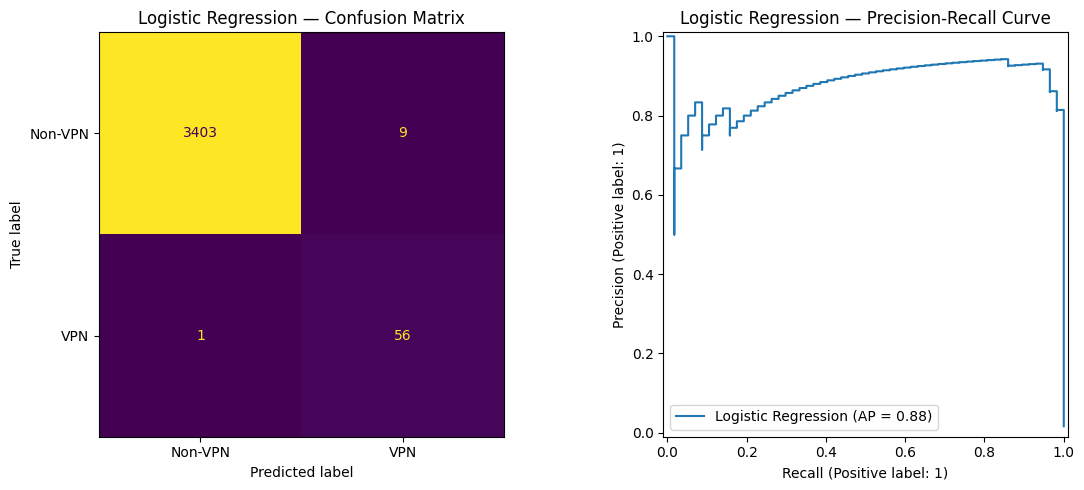

In [45]:
# Logistic Regression (binary)
lr_vpn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
lr_vpn.fit(X_train, y_vpn_train)
lr_vpn_f1, lr_vpn_auc = evaluate_binary('Logistic Regression', lr_vpn, X_val, y_vpn_val)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 400}
=== Random Forest  (macro F1: 0.9911  ROC-AUC: 1.0000) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      3412
         VPN       0.98      0.98      0.98        57

    accuracy                           1.00      3469
   macro avg       0.99      0.99      0.99      3469
weighted avg       1.00      1.00      1.00      3469



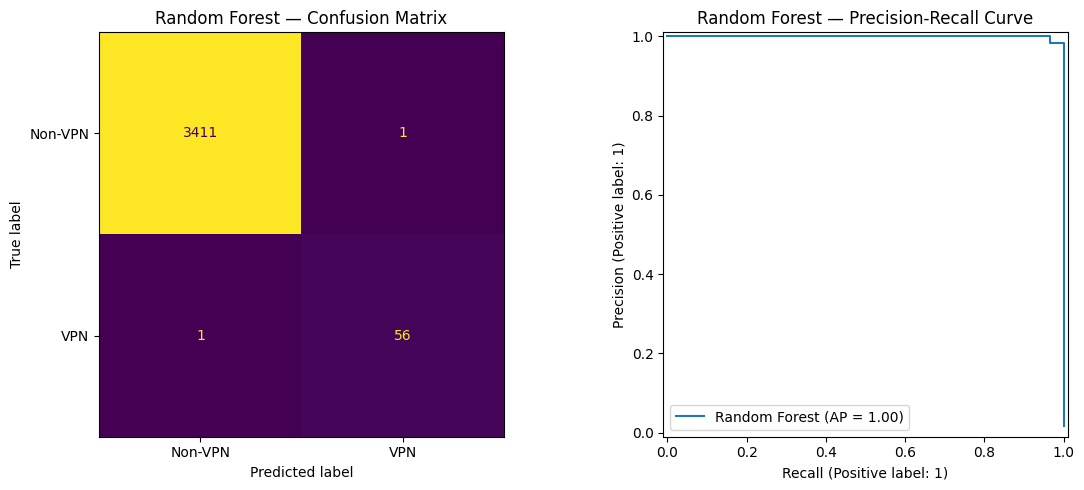

In [46]:
# Random Forest (binary)
rf_vpn_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
rf_vpn_search.fit(X_train, y_vpn_train)
print(f"Best RF params: {rf_vpn_search.best_params_}")
rf_vpn_f1, rf_vpn_auc = evaluate_binary('Random Forest', rf_vpn_search.best_estimator_, X_val, y_vpn_val)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best LGBM params: {'learning_rate': 0.05, 'min_child_samples': 30, 'n_estimators': 400, 'num_leaves': 31}
=== LightGBM  (macro F1: 1.0000  ROC-AUC: 1.0000) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      3412
         VPN       1.00      1.00      1.00        57

    accuracy                           1.00      3469
   macro avg       1.00      1.00      1.00      3469
weighted avg       1.00      1.00      1.00      3469



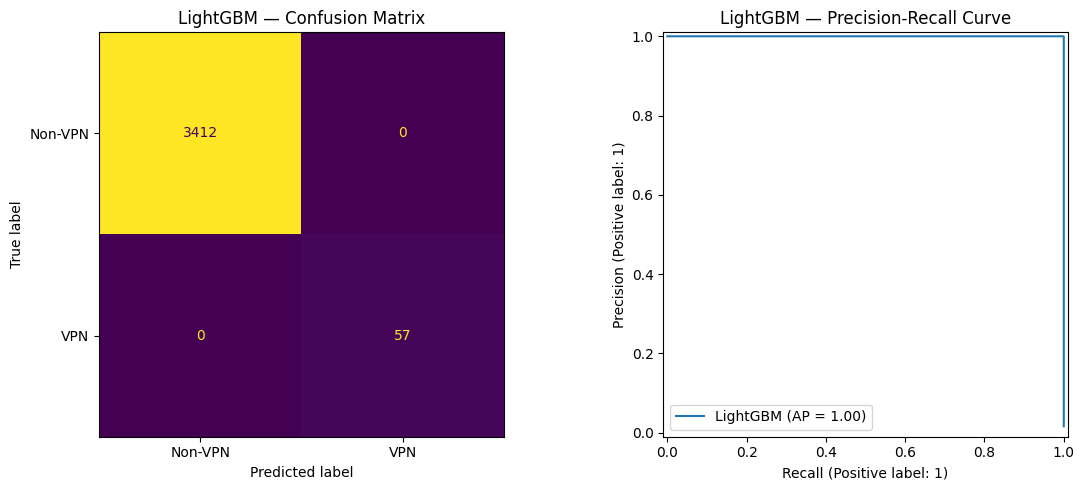

In [47]:
# LightGBM (binary)
vpn_sample_weights = y_vpn_train.map({0: 1.0, 1: y_vpn_train.value_counts()[0] / y_vpn_train.value_counts()[1]}).values

lgbm_vpn_search = GridSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    lgbm_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
lgbm_vpn_search.fit(X_train, y_vpn_train, sample_weight=vpn_sample_weights)
print(f"Best LGBM params: {lgbm_vpn_search.best_params_}")
lgbm_vpn_f1, lgbm_vpn_auc = evaluate_binary('LightGBM', lgbm_vpn_search.best_estimator_, X_val, y_vpn_val)

In [48]:
# Task B comparison
results_vpn = pd.DataFrame({
    'Model':        ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'Val macro-F1': [lr_vpn_f1, rf_vpn_f1, lgbm_vpn_f1],
    'Val ROC-AUC':  [lr_vpn_auc, rf_vpn_auc, lgbm_vpn_auc],
}).sort_values('Val macro-F1', ascending=False)

print("Task B — VPN Status Classification:")
print(results_vpn.to_string(index=False))

Task B — VPN Status Classification:
              Model  Val macro-F1  Val ROC-AUC
           LightGBM      1.000000      1.00000
      Random Forest      0.991082      0.99999
Logistic Regression      0.958283      0.99908


### Step 2.4 — Evaluate on held-out test set + SHAP analysis

=== Task A: Category (test set) ===
=== LightGBM [test]  (macro F1: 0.8443) ===
               precision    recall  f1-score   support

           C2       0.15      0.60      0.24         5
         CHAT       0.99      1.00      1.00       192
FILE_TRANSFER       1.00      0.99      1.00      2916
    STREAMING       1.00      1.00      1.00       265
         VOIP       1.00      0.98      0.99        92

     accuracy                           0.99      3470
    macro avg       0.83      0.91      0.84      3470
 weighted avg       1.00      0.99      1.00      3470



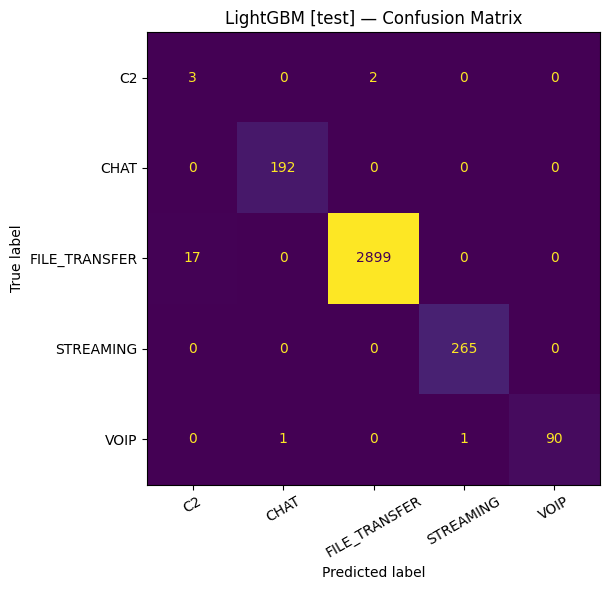

=== Task B: VPN Status (test set) ===
=== LightGBM [test]  (macro F1: 1.0000  ROC-AUC: 1.0000) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      3425
         VPN       1.00      1.00      1.00        45

    accuracy                           1.00      3470
   macro avg       1.00      1.00      1.00      3470
weighted avg       1.00      1.00      1.00      3470



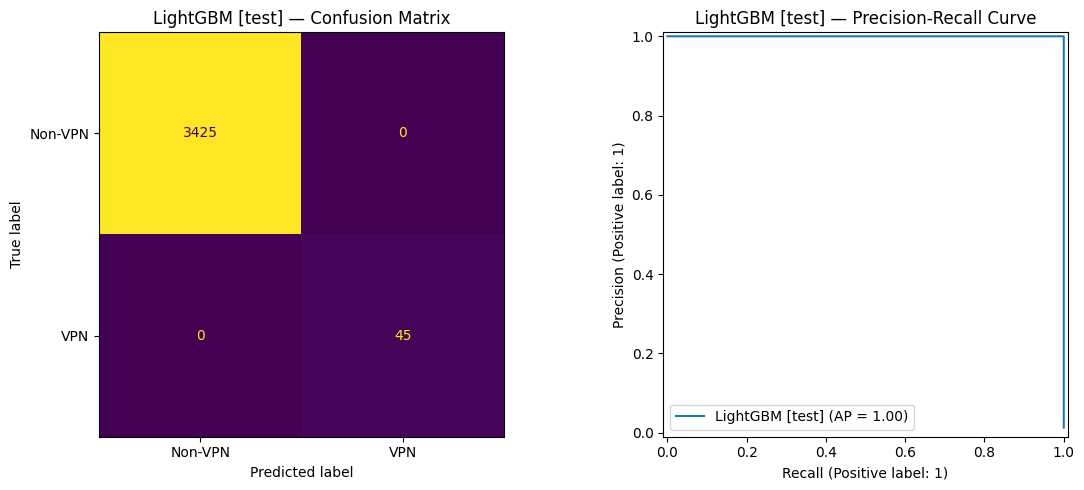

In [50]:
# Final test-set evaluation -- run ONCE after all model selection is done
# Pick the best category model and best VPN model from validation results
best_cat_model  = lgbm_search.best_estimator_   # replace if RF won
best_vpn_model  = lgbm_vpn_search.best_estimator_

print("=== Task A: Category (test set) ===")
cat_test_f1 = evaluate('LightGBM [test]', best_cat_model, X_test, y_cat_test)

print("=== Task B: VPN Status (test set) ===")
vpn_test_f1, vpn_test_auc = evaluate_binary('LightGBM [test]', best_vpn_model, X_test, y_vpn_test)

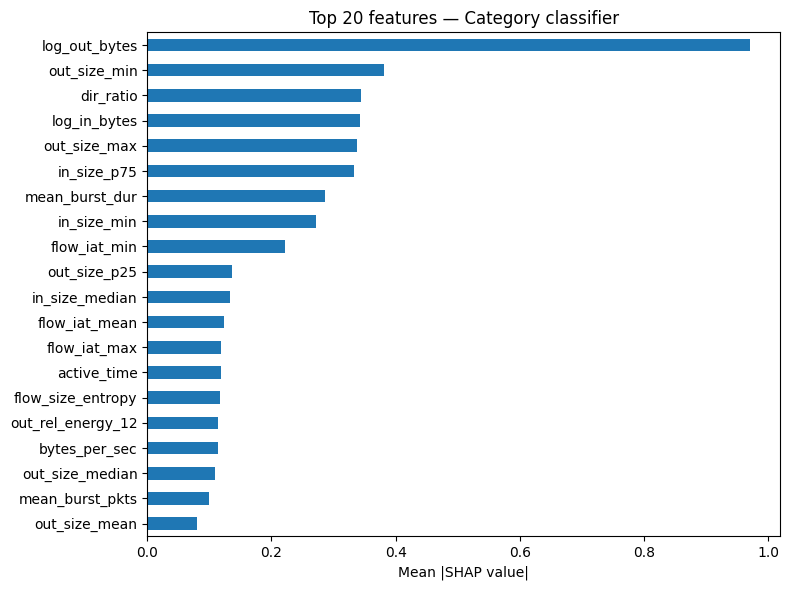

In [53]:
# SHAP feature importance -- Task A (category classification)
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer_cat = shap.TreeExplainer(best_cat_model)
X_shap = X_test.sample(min(500, len(X_test)), random_state=42)
shap_vals_cat = explainer_cat.shap_values(X_shap)

# Newer SHAP returns 3D array (n_samples, n_features, n_classes).
# Older SHAP returns a list of 2D arrays [(n_samples, n_features), ...].
# Normalise to 3D so the rest of the code works regardless of version.
import numpy as np
if isinstance(shap_vals_cat, list):
    shap_vals_cat = np.stack(shap_vals_cat, axis=-1)  # -> (n_samples, n_features, n_classes)

# Mean absolute SHAP across samples and classes -> overall feature importance
feat_importance = pd.Series(
    np.abs(shap_vals_cat).mean(axis=(0, 2)),
    index=X_shap.columns
)
top20 = feat_importance.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot.barh(ax=ax)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 features — Category classifier')
plt.tight_layout()
plt.show()

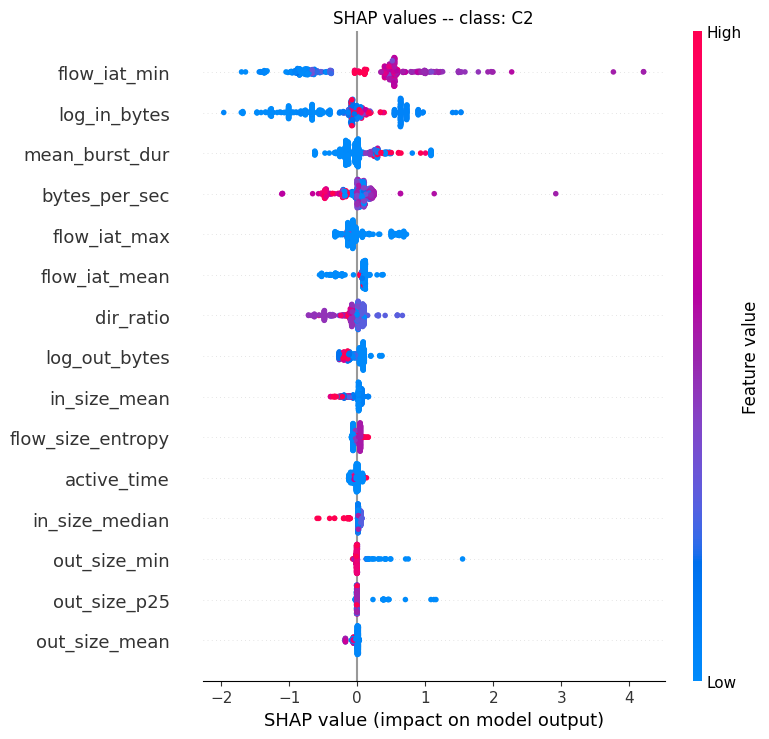

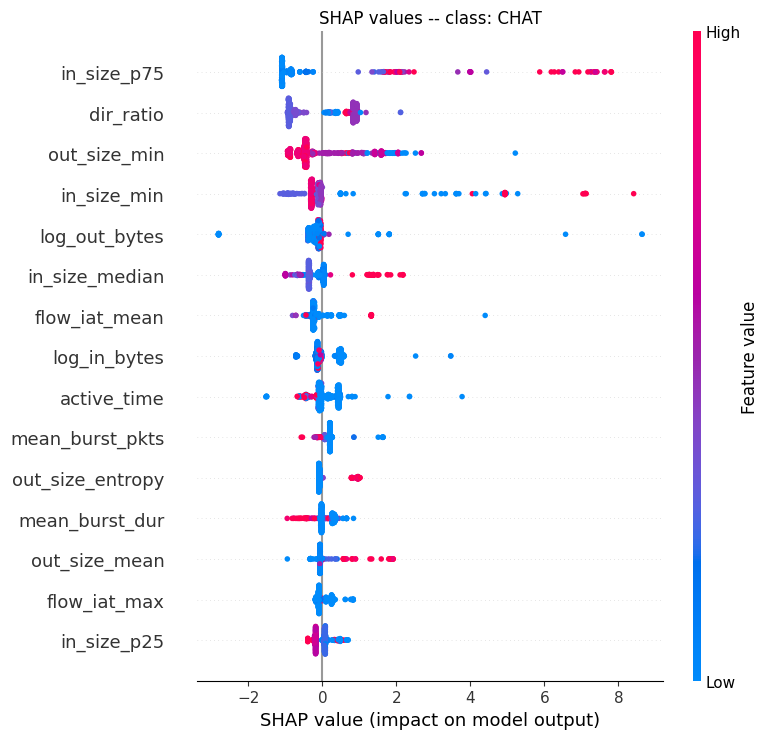

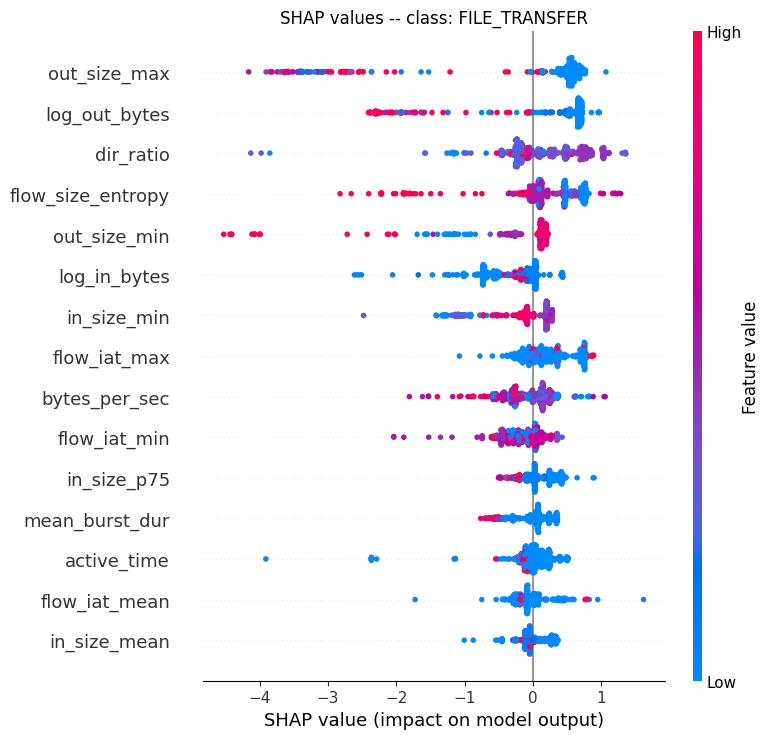

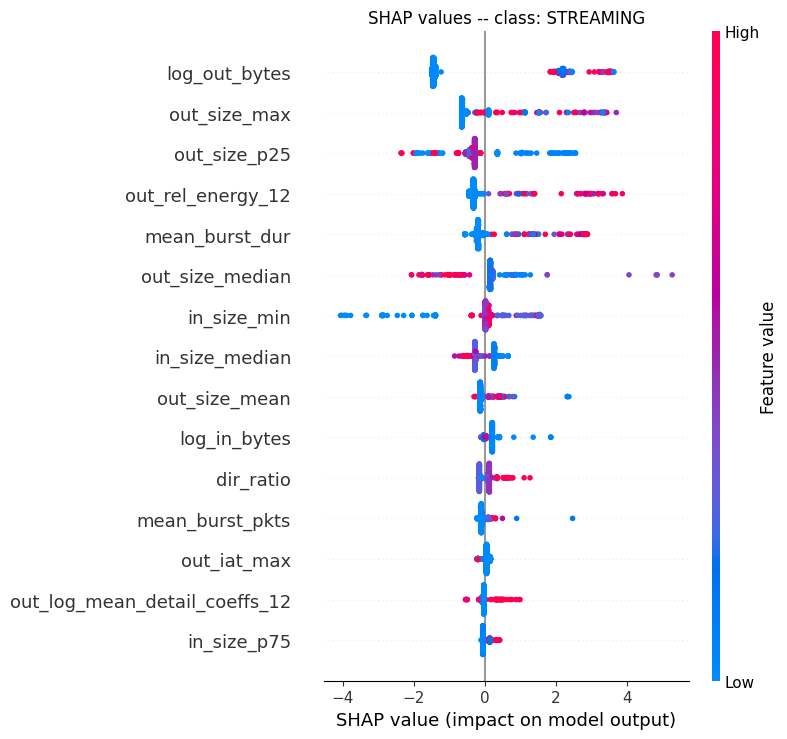

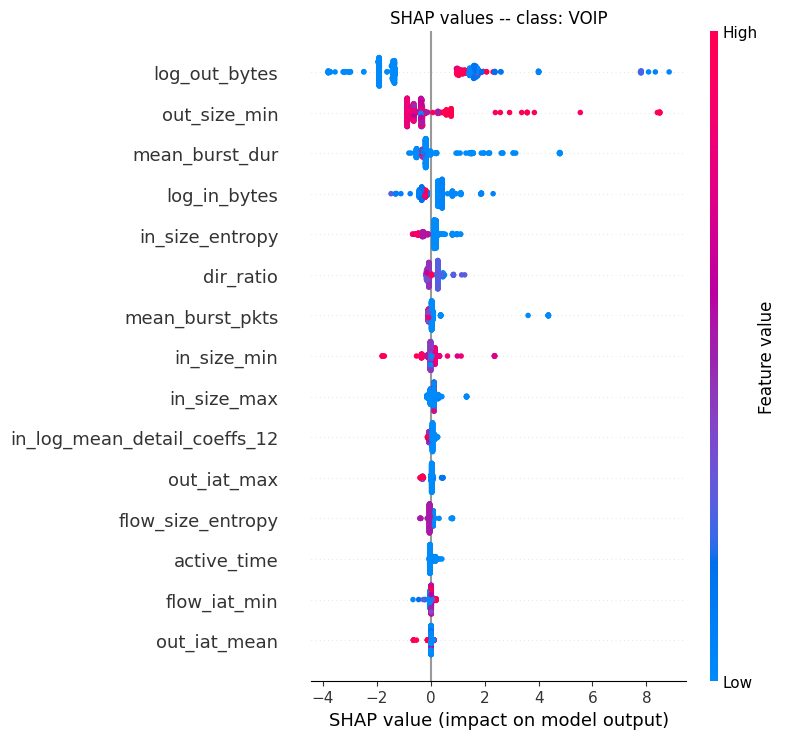

In [54]:
# SHAP beeswarm per class
category_names = best_cat_model.classes_
for i, cls in enumerate(category_names):
    shap.summary_plot(shap_vals_cat[:, :, i], X_shap, max_display=15,
                      show=False, plot_type='dot')
    plt.title(f'SHAP values -- class: {cls}')
    plt.tight_layout()
    plt.show()

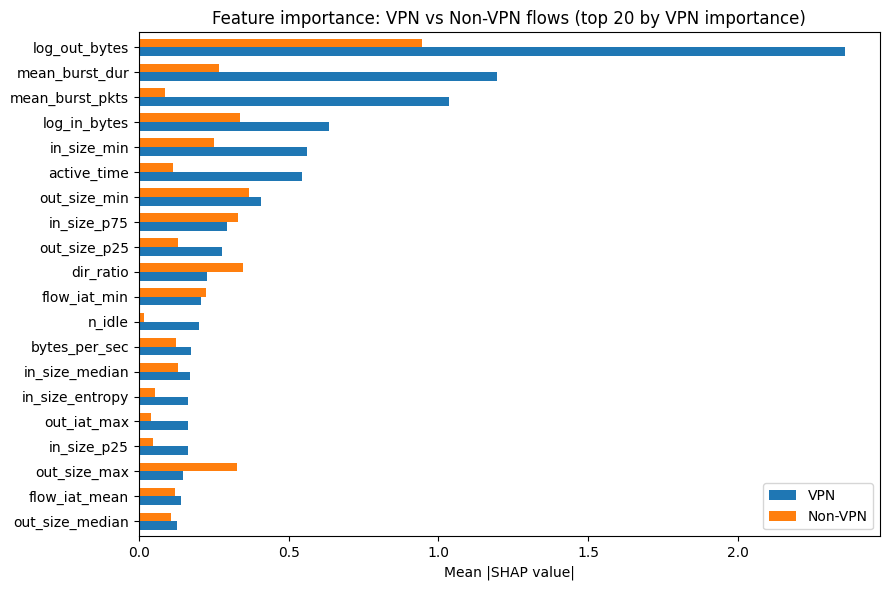

Features with largest VPN/Non-VPN importance gap:
n_idle             12.082310
mean_burst_pkts    11.803492
active_time         4.786634
mean_burst_dur      4.458097
out_iat_max         3.938443
in_size_p25         3.406293
in_size_entropy     3.058713
log_out_bytes       2.487853
in_size_min         2.247919
out_size_p25        2.140905
Name: ratio, dtype: float64


In [56]:
# Feature importance: VPN subset vs Non-VPN subset
vpn_mask_test    = y_vpn_test == 1
nonvpn_mask_test = y_vpn_test == 0

X_vpn    = X_test[vpn_mask_test.values]
X_nonvpn = X_test[nonvpn_mask_test.values].sample(min(500, nonvpn_mask_test.sum()), random_state=42)

shap_vpn    = explainer_cat.shap_values(X_vpn)
shap_nonvpn = explainer_cat.shap_values(X_nonvpn)

if isinstance(shap_vpn, list):
    shap_vpn    = np.stack(shap_vpn,    axis=-1)
    shap_nonvpn = np.stack(shap_nonvpn, axis=-1)

imp_vpn    = pd.Series(np.abs(shap_vpn).mean(axis=(0, 2)),    index=X_test.columns)
imp_nonvpn = pd.Series(np.abs(shap_nonvpn).mean(axis=(0, 2)), index=X_test.columns)

comparison = pd.DataFrame({'VPN': imp_vpn, 'Non-VPN': imp_nonvpn}).nlargest(20, 'VPN')

fig, ax = plt.subplots(figsize=(9, 6))
comparison.sort_values('VPN').plot.barh(ax=ax, width=0.7)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature importance: VPN vs Non-VPN flows (top 20 by VPN importance)')
plt.tight_layout()
plt.show()

print("Features with largest VPN/Non-VPN importance gap:")
comparison['ratio'] = comparison['VPN'] / (comparison['Non-VPN'] + 1e-9)
print(comparison['ratio'].sort_values(ascending=False).head(10))